# Results

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
results_pth = "/Users/mayajanvier/jax-phynity/data/damped_pendulum_complete/complete_aug3/model_3.419e+00..json"
results = pd.read_json(results_pth).T
results

,states,pred,loss_val,loss_op
0,"[[-0.8616502881050111, -1.682572245597839, -2....","[[-0.8616502881050111, -1.244788408279419, -1....",9.604167,0.000003
1,"[[1.02391505241394, 1.4035130739212032, 1.6833...","[[1.02391505241394, 1.226570725440979, 1.35867...",1.075058,0.000018
2,"[[-1.266593933105468, -1.656409740447998, -1.9...","[[-1.266593933105468, -1.4723138809204102, -1....",1.284507,0.00002
3,"[[0.28855118155479403, -0.6155296564102171, -1...","[[0.28855118155479403, -0.389534264802932, -0....",8.75245,0.000004
4,"[[1.654847264289856, 1.4286026954650881, 1.159...","[[1.654847264289856, 1.313455700874328, 0.9315...",1.071562,0.00003
5,"[[2.013660907745361, 2.478004217147827, 2.8584...","[[2.013660907745361, 2.438983678817749, 2.8172...",0.041859,0.000002
6,"[[-1.214775919914245, -1.601453781127929, -1.8...","[[-1.214775919914245, -1.4292263984680171, -1....",1.29175,0.00002
7,"[[1.030321478843689, 1.705892086029052, 2.2544...","[[1.030321478843689, 1.5775666236877441, 2.098...",0.027235,0.000002
8,"[[-0.5949302911758421, -1.536422491073608, -2....","[[-0.5949302911758421, -1.083818793296814, -1....",10.167678,0.000003
9,"[[-1.292472839355468, -1.4946774244308472, -1....","[[-1.292472839355468, -1.463525295257568, -1.5...",1.389377,0.000034


In [13]:
# physics only 
from networks import DampedPendulumParamPDE
from forecasters import Forecaster
model_phy = DampedPendulumParamPDE(is_complete=True, real_params=None)
net_phy = Forecaster(model_phy=model_phy, model_aug=None, is_augmented=False)


In [43]:
import jax.numpy as jnp 
def plot_trajectory(index):
    fig, ax = plt.subplots(2, 1, figsize=(10, 10))
    y0 = np.array(results["states"][index])[:,0]
    phy_out = net_phy(np.array([y0]), jnp.arange(0,20,0.5)) 
    print(phy_out.shape)

    ax[0].set_title("Position") 
    ax[0].plot(np.array(results["states"][index][0]), label="truth", color="black")
    ax[0].plot(np.array(phy_out[0,0,:]), label="eq_org", color="red")
    ax[0].plot(np.array(results["pred"][index][0]), label="pred", color="blue")
    ax[0].legend()

    ax[1].set_title("Velocity")
    ax[1].plot(np.array(results["states"][index][1]), label="truth", color="black")
    ax[1].plot(np.array(phy_out[0,1,:]), label="eq_org", color="red")
    ax[1].plot(np.array(results["pred"][index][1]), label="pred", color="blue")
    ax[1].legend()
    plt.show()


/Users/mayajanvier/jax-phynity/solvers/runge_kutta.py:359: UserWarning: Explicitly requested dtype float64 requested in zeros is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  y = jnp.zeros((len(t_eval),) + y0.shape, dtype=y0.dtype)


(1, 2, 40)


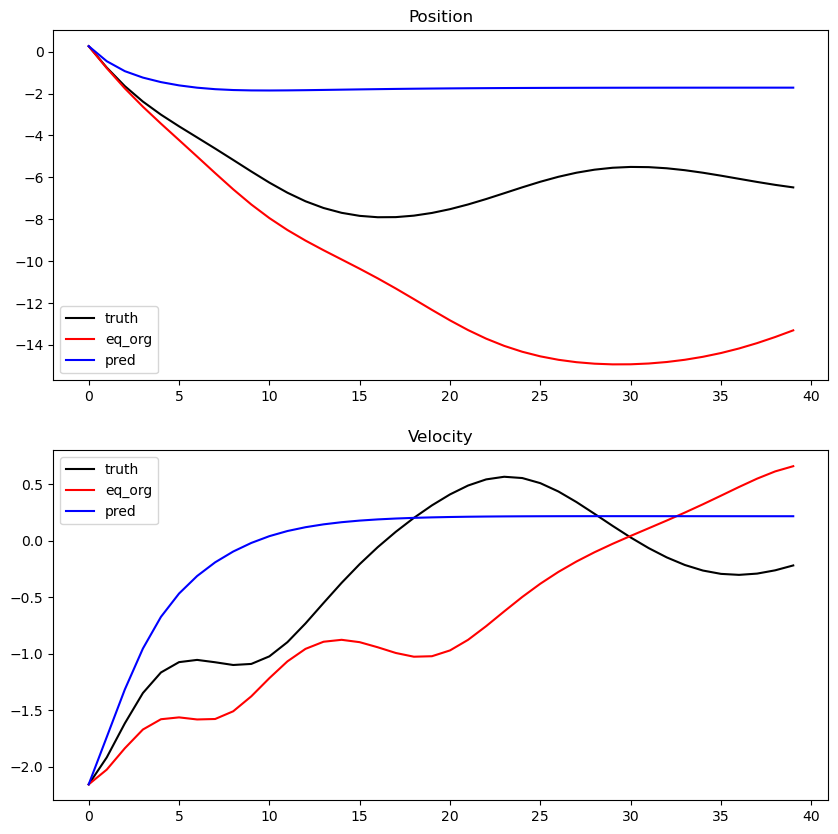

In [44]:
plot_trajectory(15)

(1, 2, 40)


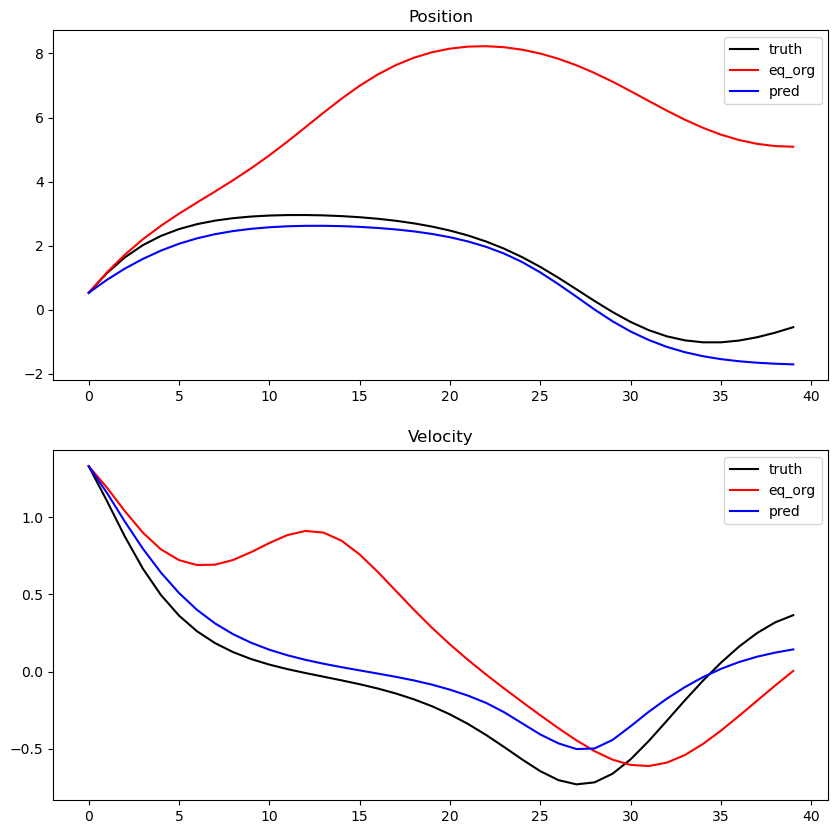

In [45]:
plot_trajectory(22)